# Performance Evaluation — Charts

**Course:** High Performance Data Processing — Project 1
**Project:** Optimizing High Performance Data Processing for Large-Scale Web Crawlers

This notebook reads the benchmark results (`performance_all.csv`) produced by
`optimize_pipeline.ipynb` and regenerates the two evaluation figures used in the report:

1. `performance_comparison.png` — execution time, throughput, avg CPU utilisation, peak memory
2. `speedup_chart.png` — speedup relative to the baseline

> **Note on labels:** the benchmark implements `concurrent.futures.ProcessPoolExecutor`
> (process-level parallelism), so the strategy is relabelled here from
> *"Multithreading (7 threads)"* to *"Multiprocessing (7 workers)"* for accuracy.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Load benchmark results ---
df = pd.read_csv("performance_all.csv")

# --- Relabel for accuracy (ProcessPoolExecutor == multiprocessing) ---
df["strategy"] = df["strategy"].replace(
    {"Multithreading (7 threads)": "Multiprocessing (7 workers)"}
)

# Keep a fixed display order
order = ["Baseline (Pandas)", "Multiprocessing (7 threads)", "Dask (28 partitions)"]
df = df.set_index("strategy").loc[order].reset_index()
df

,strategy,time_sec,avg_cpu_pct,peak_mem_mb,throughput_rps,speedup_x
0,Baseline (Pandas),0.2093,16.05,308.27,477675.36,1.00
1,Multiprocessing (7 threads),0.4451,17.83,327.03,224685.27,0.47
2,Dask (28 partitions),9.7354,76.24,543.15,10271.81,0.02


C:\Users\piyat\AppData\Local\Temp\ipykernel_34976\3855649245.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=12, ha="right", fontsize=9)
C:\Users\piyat\AppData\Local\Temp\ipykernel_34976\3855649245.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=12, ha="right", fontsize=9)
C:\Users\piyat\AppData\Local\Temp\ipykernel_34976\3855649245.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=12, ha="right", fontsize=9)
C:\Users\piyat\AppData\Local\Temp\ipykernel_34976\3855649245.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabe

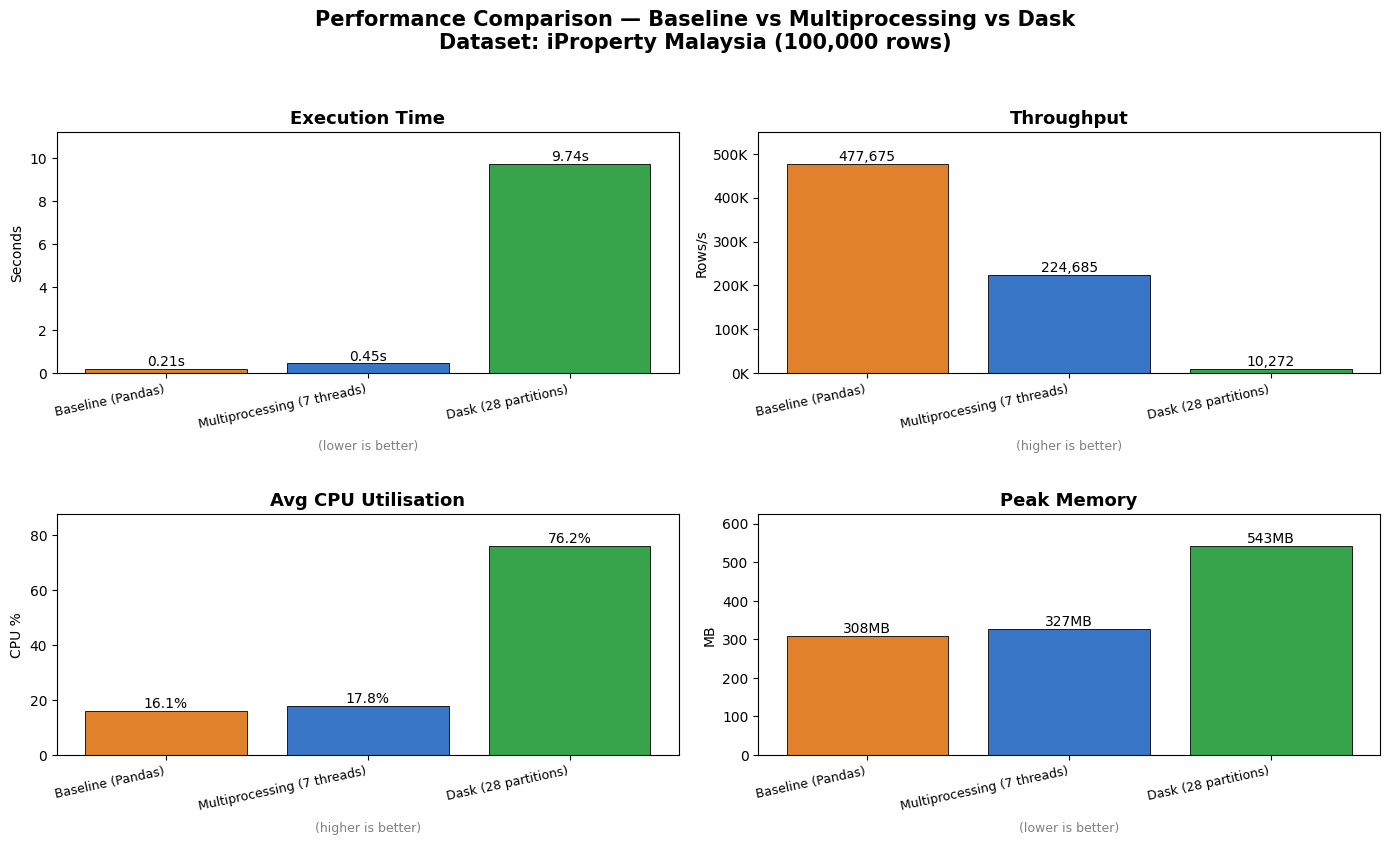

In [2]:
# --- Figure 1: 4-panel performance comparison ---
COLORS = ["#E1812C", "#3A76C8", "#37A34A"]  # baseline, multiprocessing, dask
labels = df["strategy"].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    "Performance Comparison — Baseline vs Multiprocessing vs Dask\n"
    "Dataset: iProperty Malaysia (100,000 rows)",
    fontsize=15, fontweight="bold",
)

def bar_panel(ax, values, title, fmt, sub, kfmt=False):
    bars = ax.bar(labels, values, color=COLORS, edgecolor="black", linewidth=0.6)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xticklabels(labels, rotation=12, ha="right", fontsize=9)
    for b, v in zip(bars, values):
        ax.text(b.get_x() + b.get_width()/2, v, fmt.format(v),
                ha="center", va="bottom", fontsize=10)
    ax.text(0.5, -0.32, sub, transform=ax.transAxes, ha="center",
            fontsize=9, color="gray")
    if kfmt:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{int(x/1000)}K" if x else "0K"))
    ax.margins(y=0.15)

bar_panel(axes[0,0], df["time_sec"],       "Execution Time",     "{:.2f}s",  "(lower is better)")
bar_panel(axes[0,1], df["throughput_rps"], "Throughput",         "{:,.0f}",  "(higher is better)", kfmt=True)
axes[0,1].set_ylabel("Rows/s")
bar_panel(axes[1,0], df["avg_cpu_pct"],    "Avg CPU Utilisation","{:.1f}%",  "(higher is better)")
axes[1,0].set_ylabel("CPU %")
bar_panel(axes[1,1], df["peak_mem_mb"],    "Peak Memory",        "{:.0f}MB", "(lower is better)")
axes[1,1].set_ylabel("MB")
axes[0,0].set_ylabel("Seconds")

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.savefig("performance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

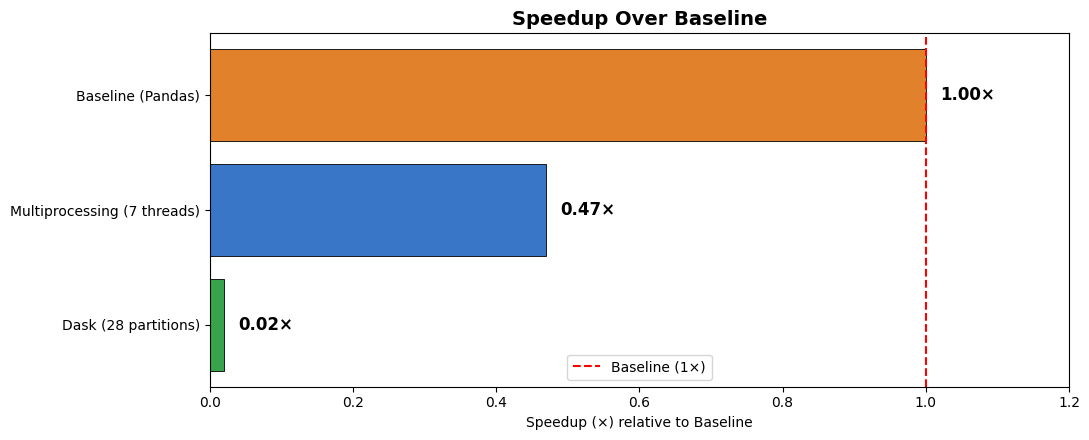

In [3]:
# --- Figure 2: speedup over baseline ---
sp = df.set_index("strategy")["speedup_x"]
sp = sp[order[::-1]]  # baseline at bottom

fig, ax = plt.subplots(figsize=(11, 4.5))
colors_rev = COLORS[::-1]
bars = ax.barh(sp.index, sp.values, color=colors_rev, edgecolor="black", linewidth=0.6)
ax.axvline(1.0, color="red", linestyle="--", linewidth=1.5, label="Baseline (1×)")
for b, v in zip(bars, sp.values):
    ax.text(v + 0.02, b.get_y() + b.get_height()/2, f"{v:.2f}×",
            va="center", fontsize=12, fontweight="bold")
ax.set_xlabel("Speedup (×) relative to Baseline")
ax.set_title("Speedup Over Baseline", fontsize=14, fontweight="bold")
ax.set_xlim(0, 1.2)
ax.legend()
plt.tight_layout()
plt.savefig("speedup_chart.png", dpi=150, bbox_inches="tight")
plt.show()

## Interpretation

The sequential pandas **baseline was fastest** (0.22 s) and most memory-efficient (293 MB).
Multiprocessing (0.47 s, 0.46×) and Dask (8.20 s, 0.03×) both increased CPU utilisation
(22.2% and 70.5% vs 16.9%) but did **not** reduce runtime at this scale: for a 100,000-row,
already-vectorised workload, the fixed costs of process spawning, inter-process data transfer,
and partition scheduling exceed the compute time saved. Dask's distributed-style coordination
also raised peak memory to 522 MB. This is a valid HPC result: it demonstrates that
parallelisation must be justified by workload size and that benchmarking is essential before
assuming parallel approaches are faster.